# Overview

This notebook builds and trains a Roberta transformer model which predicts the sentiment (+ / - / neutral/mixed) of given text. The data source is google reviews of various restaurants 

More information on Roberta can be found at https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/tree/main

In [45]:
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import numpy as np
from torch.optim import lr_scheduler

import random

def set_seed(seed):
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if using multi-GPU.
        
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python's random module.
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False

set_seed(1000)

In [31]:
# Set this for autonaming of various files
rest_type = 'veg'

# Import pre-split datasets for train, val and test cycles
df_train = pd.read_csv(f'./data/{rest_type}-train.csv')
df_val = pd.read_csv(f'./data/{rest_type}-val.csv')
df_test = pd.read_csv(f'./data/{rest_type}-test.csv')

In [32]:
df_test

,rating,text,pnn,lstm-neg,lstm-mixed,lstm-pos,lstm-pred
0,5,Really good food. I would recommend the BLT.,2,0.000191,0.065677,0.934132,2
1,5,Love it,2,0.001472,0.034975,0.963553,2
2,5,Their food is always fresh and amazing.,2,0.000018,0.000607,0.999375,2
3,5,We eat here about once every two weeks and the...,2,0.000098,0.000555,0.999347,2
4,5,Great,2,0.014054,0.089928,0.896018,2
...,...,...,...,...,...,...,...
58650,2,Window staff was unkempt and rude. Food was un...,0,0.999625,0.000049,0.000326,0
58651,2,Need to not mess up orders.,0,0.721543,0.025758,0.252699,0
58652,2,Went in the evening. Meat was pre sliced and i...,0,0.998102,0.000798,0.001100,0
58653,2,Usually a pretty good place to eat but I won't...,0,0.992310,0.002801,0.004889,0


## Text processing
- Turn into lowercase
- Tokenize the inputs
- Create column for + / - / neutral review labels

In [33]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def preprocess_text(text):
    # Some reviews are only numbers (Why? I don't know). Review should always be treated as a string
    text = str(text)
    
    # This appears in some reviews
    text = text.replace('(Translated by Google)', ' ')
    text = text.replace('\n', ' ')

    # Convert to lowercase
    text = text.lower()
    
    # Remove non letter or number entries
    # BERT does OK with numbers is seems
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

# Process the text for better classification
df_train['clean-text'] = df_train['text'].apply(preprocess_text)
df_val['clean-text'] = df_val['text'].apply(preprocess_text)
df_test['clean-text'] = df_test['text'].apply(preprocess_text)

In [35]:
# Turn ratings into +/-/neutral
def pnn(n):
    if n in {1,2}: return 0 # negative
    elif n in {4,5}: return 2 # positive
    else: return 1 # "neutral"

df_train['pnn'] = df_train['rating'].apply(pnn)
df_val['pnn'] = df_val['rating'].apply(pnn)
df_test['pnn'] = df_test['rating'].apply(pnn)

In [22]:
print('Train set sample')
print(df_train.sample(5))
print()

print('Eval set sample')
print(df_val.sample(5))
print()


print('Test set sample')
print(df_test.sample(5))
print()

Train set sample
        rating                                               text  pnn
118777       5                      delicious  original delicioso    2
159731       5                    love the tacos and their coffee    2
231346       4  they have the best breakfast so yummy the only...    2
17071        5                                               good    2
433158       1  if i could rate a 0 i would i go here all the ...    0

Eval set sample
       rating                                               text  pnn
82253       2  better off going up to the north point locatio...    0
73984       1  just check what you got before you walk away t...    0
3410        5                      great chorizo tacos very busy    2
31540       5     love this place excellent food excellent price    2
13673       5  every time i come to this location my order is...    2

Test set sample
       rating                                               text  pnn  \
56378       2  slow service wo

## Create Roberta instance
- Skip this step if continuing training

In [7]:
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from transformers import AutoModelForSequenceClassification, TFAutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoConfig, get_linear_schedule_with_warmup

model_name = f"cardiffnlp/twitter-roberta-base-sentiment-latest"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

# Model stats
#print(model)
print('Device: ', device)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Device:  cuda


In [12]:
# Summary stats of model
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                            Param #
RobertaForSequenceClassification                                  --
├─RobertaModel: 1-1                                               --
│    └─RobertaEmbeddings: 2-1                                     --
│    │    └─Embedding: 3-1                                        38,603,520
│    │    └─Embedding: 3-2                                        394,752
│    │    └─Embedding: 3-3                                        768
│    │    └─LayerNorm: 3-4                                        1,536
│    │    └─Dropout: 3-5                                          --
│    └─RobertaEncoder: 2-2                                        --
│    │    └─ModuleList: 3-6                                       85,054,464
├─RobertaClassificationHead: 1-2                                  --
│    └─Linear: 2-3                                                590,592
│    └─Dropout: 2-4                                               --

## Test the output of an untrained model
Roberta is very well-trained out of the box, so it should perform well

In [8]:
# Simple test cycle of the untrained model
def predict_sentiment(text):
    inputs = tokenizer(text, padding="max_length", truncation=True, max_length=128, return_tensors="pt")
    
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    inputs = {'input_ids':input_ids, 'attention_mask':attention_mask}
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        
    return predicted_class, probabilities.tolist()

# Enter your text here
review = 'Sucks!'
label, probs = predict_sentiment(review)
meaning = ['negative', 'neutral', 'good']

print(f'Review: {review}')
print(f'Predicted rating: {label} ({meaning[label]})')
print(f'Probabilities: 0 ({probs[0][0]*100:.2f}%) | 1 ({probs[0][1]*100:.2f}%) | 2 ({probs[0][2]*100:.2f}%)')

Review: Sucks!
Predicted rating: 0 (negative)
Probabilities: 0 (84.86%) | 1 (12.78%) | 2 (2.35%)


## Script for autogenerating certain training metrics
- Confusion matrix
- runtime

In [9]:
import datetime
import matplotlib.pyplot as plt

# Prints total runtime of train/val cycles
def runtime(start_time):
    end_time = time.time()
    s = end_time - start_time

    h = s // 3600
    s = s - 3600*h

    m = s // 60
    s = s - 60*m

    print(f'Total runtime: {int(h)} hr {int(m)} min {s:.1f} sec')
    return 

In [10]:
import seaborn as sns

# Prints confusion matrix and saves to file
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    
    current_time = datetime.datetime.now()
    file_name = f'./sshots/model-{rest_type}-{current_time.strftime("%Y-%m-%d--%H%m")}.png'
    plt.savefig(file_name)
    
    plt.show()
    return

## Training Roberta
- Create datasets and dataloaders
- Compute weights for imbalances classes
- Create train/val/test cycle with early stopping (f1 used as metric)

In [11]:
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

# Create dataset from data
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length #store max length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        inputs = self.tokenizer(
            text,
            padding="max_length", #important
            truncation=True, #important
            max_length=self.max_length, #important
            return_tensors="pt")
        
        input_ids = inputs['input_ids'].flatten()
        attention_mask = inputs['attention_mask'].flatten()
        label_tensor = torch.tensor(label)

        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': label_tensor}

In [13]:
from sklearn.utils import class_weight

# Ratings are not evenly distributed, this creates class weights
def calculate_class_weights(labels):
    class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    return torch.tensor(class_weights, dtype=torch.float)

In [36]:
# Export the text and ratings to a list, this part is necessary otherwise pandas keeps the index
X_train = df_train['clean-text'].values.tolist()
y_train = df_train['pnn'].values.tolist()

X_val = df_val['clean-text'].values.tolist()
y_val = df_val['pnn'].values.tolist()

X_test = df_test['clean-text'].values.tolist()
y_test = df_test['pnn'].values.tolist()

# Batch size set as a power of 2
# monitor RAM use in the terminal with "watch -n5 nvidia-smi"
batch_size = 64
max_length = 128
learning_rate = 2e-5
weight_decay = .01

## Freeze the base BERT parameters and only train the classification layer
for param in model.roberta.parameters():
    param.requires_grad = False

# Create datasets and dataloaders
train_dataset = SentimentDataset(X_train, y_train, tokenizer, max_length=max_length)
val_dataset = SentimentDataset(X_val, y_val, tokenizer, max_length=max_length)
test_dataset = SentimentDataset(X_test, y_test, tokenizer, max_length=max_length)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Adjust learning rate and weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate))

# Calculate class weights of the train set
class_weights = calculate_class_weights(y_train).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print('Class weights:', class_weights)

Class weights: tensor([1.6883, 2.4690, 0.4993], device='cuda:0')


In [24]:
def evaluate_model(model, dataloader, confusion=False):
    # Put in evaluation mode
    print('Evaluating...', end='\r')
    model.eval()
    
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy() #put back on cpu
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    ## Accuracy and F1 used to determine early exit
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return acc, f1

In [46]:
def early_stopping(model, train_dataloader, val_dataloader, optimizer, epochs=100, patience=5, max_grad_norm=1.0, device='cuda'):
    m_name = f'./saved-models/roberta-{rest_type}.pth'
    
    # Keep track of some data
    start_time = time.time()
    accs, losses, f1s = [], [], []

    # Learning rate scheduler
    #num_training_steps = len(train_dataloader) * epochs
    #scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=2, num_training_steps=num_training_steps)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0)  
    
    # Set best value as low as possible to start
    best_val_f1 = -np.inf
    patience_counter = 0

    for epoch in range(epochs):
        # Put model in train mode
        model.train()
        train_loss = 0
    
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}"):
            optimizer.zero_grad()
    
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            ## Evaluate model at the inputs
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
    
            ## Evaluate loss and backpropogate
            loss = outputs.loss
            train_loss += loss.item()
            loss.backward()

            ## Clip gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            ## Stepforward the optimizer and scheduler
            optimizer.step()
            scheduler.step()

        # Keep track of loss
        trin_loss = train_loss / len(train_dataloader)
        losses.append(loss)
        
        # Validation cycle
        val_acc, val_f1 = evaluate_model(model=model, dataloader=val_dataloader)
        
        accs.append(val_acc)
        f1s.append(val_f1)

        # Keep track of progress
        print(f'Train loss: {loss:.5f} | Val acc: {100*val_acc:.2f}%, F1 {val_f1:.5f}')
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            
            # Save the best model
            torch.save(model.state_dict(), m_name)
            print('--New best--')
            
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered')
                break 

    # Print total runtime
    runtime(start_time)

    # Load the best model and return it
    model.load_state_dict(torch.load(m_name))
    return model

In [47]:
# Train the model here
model = early_stopping(model=model, 
                       train_dataloader=train_dataloader, 
                       val_dataloader=val_dataloader, 
                       optimizer=optimizer, 
                       epochs=100, 
                       patience=5,
                       max_grad_norm=1.0,
                       device=device)

Epoch 1: 100%|██████████████████████████████████████████████| 7503/7503 [19:31<00:00,  6.41it/s]


Train loss: 0.37620 | Val acc: 83.51%, F1 0.82414
--New best--


Epoch 2: 100%|██████████████████████████████████████████████| 7503/7503 [19:23<00:00,  6.45it/s]


Train loss: 0.83109 | Val acc: 83.49%, F1 0.81613


Epoch 3: 100%|██████████████████████████████████████████████| 7503/7503 [19:22<00:00,  6.46it/s]


...

Epoch 5: 100%|██████████████████████████████████████████████| 7503/7503 [19:22<00:00,  6.45it/s]


Train loss: 0.14577 | Val acc: 83.58%, F1 0.82096


Epoch 6: 100%|██████████████████████████████████████████████| 7503/7503 [19:23<00:00,  6.45it/s]


Train loss: 0.10766 | Val acc: 83.55%, F1 0.82074
Early stopping triggered
Total runtime: 2 hr 23 min 22.0 sec


/tmp/ipykernel_2142317/447501169.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(m_name))


## Final prediction
- Plots confusion matrix on testing data
- Computes accuracy and f1
- Writes probs to appropriate column of testing dataframe, then saves everything

100%|█████████████████████████████████████████████████████████| 917/917 [02:19<00:00,  6.55it/s]


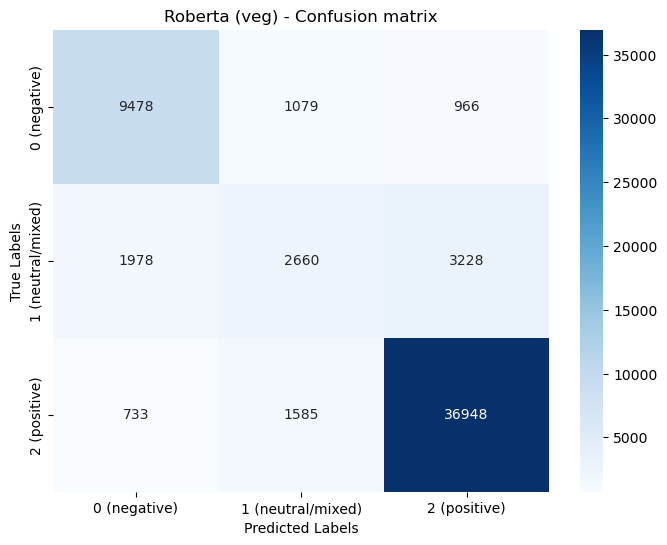

Test acc: 83.69%, F1 0.82636


In [48]:
# Make final prediction
def make_prediction(model, dataloader):
    model.eval()
    
    all_probs, all_preds, all_labels = [], [], []
    
    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            
            labels = batch["labels"].to(device)
            all_labels.extend(labels.cpu().numpy())
            
            outputs = model(input_ids, attention_mask=attention_mask)
            
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.extend(probs)
            
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
    
    plot_confusion_matrix(cm=confusion_matrix(np.array(df_test['pnn']), np.array(all_preds)), 
                            classes=['0 (negative)', '1 (neutral/mixed)', '2 (positive)'], 
                            title=f'Roberta ({rest_type}) - Confusion matrix')

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return all_probs, acc, f1

# Make final prediction
probs, acc, f1 = make_prediction(model=model, dataloader=test_dataloader)
print(f'Test acc: {100*acc:.2f}%, F1 {f1:.5f}')

In [49]:
# Extract information (this could be made better ... )
def probs_to_columns(probs):
    neg, neut, pos, pred = [], [], [], []
    for row in probs:
        neg.append(row[0])
        neut.append(row[1])
        pos.append(row[2])
        pred.append(np.argmax(row).item())
        
    return neg, neut, pos, pred
        
neg, mixed, pos, pred = probs_to_columns(probs)

# Write columns
df_test['roberta-neg'] = neg
df_test['roberta-mixed'] = mixed
df_test['roberta-pos'] = pos
df_test['roberta-pred'] = pred

# Save final model
df_test.to_csv(f'./data/{rest_type}-test.csv', index=False)